# Training example

This notebook shows an example to train the unfolded Chambolle-Pock algorithm

In [1]:
import deepinv as dinv
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.io as sio
mpl.rcParams.update(mpl.rcParamsDefault)
from PIL import Image
from deepinv.loss.metric import PSNR
perf_psnr = PSNR()
from scipy.io import loadmat
from scipy.io import savemat
import torch.nn as nn
from torch.utils.data import DataLoader
import time

from utils.database_gradient_descent import gradient_descent_database
from utils.create_database import CustomDataset
from utils.CP_unfolded import cp_unfolded_OpLin as cp_oplin, cp_unfolded_l as cp, cp_unfolded_Lexp as cp_l, cp_unfolded_LSTexp as cp_lst
from utils.config import TrainConfig

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Unrolled Chambolle–Pock Layer

One layer of the unrolled Chambolle–Pock algorithm applied to the estimation of the COVID-19 reproduction number can be written as:

$$
\left\{
\begin{aligned}
\boldsymbol{\mathsf{Q}}^{[k+1]} &=
\mathrm{prox}_{\boldsymbol{\sigma}^{[k]} (\boldsymbol{\lambda}^{[k]}\lVert \cdot \rVert_1)^*}
\left(
\boldsymbol{\mathsf{Q}}^{[k]} +
\boldsymbol{\sigma}^{[k]} \boldsymbol{\mathsf{M}}^{[k]} \overline{\boldsymbol{\mathsf{R}}}^{[k]}
\right), \\[0.4em]
\boldsymbol{\mathsf{R}}^{[k+1]} &=
\mathrm{prox}_{\boldsymbol{\tau}^{[k]} \mathsf{D}_{\mathrm{KL}}\left(\boldsymbol{\mathsf{Z}} \mid \boldsymbol{\cdot} \odot \Phi^{\boldsymbol{\mathsf{Z}}}\right)}
\left(
\boldsymbol{\mathsf{R}}^{[k]} -
\boldsymbol{\tau}^{[k]} (\boldsymbol{\mathsf{M}}^{[k]})^\top \boldsymbol{\mathsf{Q}}^{[k+1]}
\right), \\[0.4em]
\overline{\boldsymbol{\mathsf{R}}}^{[k+1]} &= 2\boldsymbol{\mathsf{R}}^{[k+1]} - \boldsymbol{\mathsf{R}}^{[k]} .
\end{aligned}
\right.
$$

---

### Learnable Parameters

Depending on the chosen model, different parameters can be learned:

- **`choix_model = 'Lexp'`**  
  Learning a single regularization parameter per layer  
  $$
  \Theta = \underline{\lambda} = (\lambda^{[k]})_{k=1,\dots,K}
  $$

- **`choix_model = 'LSTexp'`**  
  Learning algorithmic parameters $\underline{\sigma} = (\sigma^{[k]})_{k=1,\dots,K}$,  
  $\underline{\tau} = (\tau^{[k]})_{k=1,\dots,K}$ and a regularization parameter $\underline{\lambda}$ per layer  
  $$
  \Theta = \{\underline{\lambda}, \underline{\sigma}, \underline{\tau}\}
  $$

- **`choix_model = 'OpLin'`**  
  Learning $\underline{\sigma}$, $\underline{\tau}$, and a linear operator  
  $\mathsf{M}$ per layer, implemented as a filter of size 3.  
  This replaces the second derivative operator $\mathsf{D}_2$ with a more general
  filtering operator that varies across layers:
  $$
  \Theta = \{\underline{\sigma}, \underline{\tau}, \mathsf{M}_{\underline{AB}}\},
  $$

  $$
  \mathsf{M}_{\underline{AB}}^{[k]} =
  \begin{bmatrix}
  a^{[k]} & b^{[k]} & a^{[k]} & 0 & \cdots & 0 \\
  0 & a^{[k]} & b^{[k]} & a^{[k]} & 0 & \cdots \\
  \vdots & \vdots & \vdots & \ddots & \ddots & \vdots \\
  0 & \cdots & a^{[k]} & b^{[k]} & a^{[k]} & 0 \\
  0 & \cdots & 0 & a^{[k]} & b^{[k]} & a^{[k]}
  \end{bmatrix}
  $$

- **`choix_model = 'OpLin_vect'`**  
  Learning $\underline{\sigma}$, $\underline{\tau}$, and a linear operator
  $\mathsf{M}$ per layer as a filter of size 25:
  $$
  \Theta = \{\underline{\sigma}, \underline{\tau}, \mathsf{M}_{\underline{C}}\},
  $$

  $$
  \mathsf{M}_{\underline{C}}^{[k]} =
  \begin{bmatrix}
  c_1^{[k]} & \cdots & c_{25}^{[k]} & 0 & \cdots & 0 \\
  0 & c_1^{[k]} & \cdots & c_{25}^{[k]} & 0 & \cdots \\
  \vdots & \vdots & \vdots & \ddots & \ddots & \vdots
  \end{bmatrix}
  $$

  The filter size is motivated by the characteristic time constant of the COVID-19 epidemic,
  corresponding to a maximum infectious period of 25 days.

- **`choix_model = 'OpLin_mat'`**  
  Learning a fully unconstrained linear operator $\mathsf{M}$,
  shared across all layers:
  $$
  \Theta = \Gamma =
        \begin{bmatrix}
        \gamma_{1, 1} & \gamma_{1, 2}  & \cdots & \gamma_{1, T} \\
        \gamma_{2, 1} & \gamma_{2, 2}   & \cdots & \gamma_{2, T} \\
        \vdots & \vdots & \vdots & \vdots \\
        \gamma_{T-3, 1} & \cdots  & \gamma_{T-3, T-1} & \gamma_{T-3, T} \\
        \gamma_{T-2, 1} & \cdots & \gamma_{T-2, T-1} & \gamma_{T-2, T}
        \end{bmatrix}
  $$

---

### Config settings

In addition to classic settings such as the number of epochs or the number of layers in the network, it is possible to set up the following settings: 
- **`device`**: device on which to perform the calculation, basically CPU or CUDA
- **`choix_loss`**: loss used for learning, L1 or L2
- **`R_init_type`**: input $\mathsf{R}^{[0]}$ of the network. Choice between $\mathsf{R}^{[0]} = \mathsf{R}^{[\mathrm{MLE}]}$ and $\mathsf{R}^{[0]} = \boldsymbol{1}$
- **`norm_type`**: normalization of the data. Choice between $\mathrm{std}(\mathsf{Z})$ and $\mathrm{max}(\mathsf{Z})$

In [2]:
# Set up the config settings
config = TrainConfig(
    device = "cpu",
    choix_model = 'OpLin_mat',
    choix_loss = 'L2',
    nepoch = 10000,
    K_layer = 10,
    nbatch_train = 20,
    nbatch_validation = 4,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adam',
    dataset_train = 'dataset_covid/data_train',
    dataset_validation = 'dataset_covid/data_validation',
    norm_type = 'std',
    R_init_type = 'MLE',
)

In [3]:
# Train the network with gradient descent
model, model_best_validation, out, loss_value_train_all, loss_value_validation_all = gradient_descent_database(config)

if config.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model.scheduler.state_dict()

std
std
epoch 0/10000
epoch 100/10000
epoch 200/10000
epoch 300/10000
epoch 400/10000
epoch 500/10000
epoch 600/10000
epoch 700/10000
epoch 800/10000
epoch 900/10000
epoch 1000/10000
epoch 1100/10000
epoch 1200/10000
epoch 1300/10000
epoch 1400/10000
epoch 1500/10000
epoch 1600/10000
epoch 1700/10000
epoch 1800/10000
epoch 1900/10000
epoch 2000/10000
epoch 2100/10000
epoch 2200/10000
epoch 2300/10000
epoch 2400/10000
epoch 2500/10000
epoch 2600/10000
epoch 2700/10000
epoch 2800/10000
epoch 2900/10000
epoch 3000/10000
epoch 3100/10000
epoch 3200/10000
epoch 3300/10000
epoch 3400/10000
epoch 3500/10000
epoch 3600/10000
epoch 3700/10000
epoch 3800/10000
epoch 3900/10000
epoch 4000/10000
epoch 4100/10000
epoch 4200/10000
epoch 4300/10000
epoch 4400/10000
epoch 4500/10000
epoch 4600/10000
epoch 4700/10000
epoch 4800/10000
epoch 4900/10000
epoch 5000/10000
epoch 5100/10000
epoch 5200/10000
epoch 5300/10000
epoch 5400/10000
epoch 5500/10000
epoch 5600/10000
epoch 5700/10000
epoch 5800/10000
e

In [4]:
# Save the final model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'model_exemple/model_exemple_covid_OpLin_mat.pth')

# Save the best model on validation dataset
torch.save({
    'model_state_dict': model_best_validation.state_dict(),
    'optimizer_state_dict': model_best_validation.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'model_exemple/model_exemple_covid_best_validation_OpLin_mat.pth')

# Save data
with torch.no_grad():
   dico = {'R' : out, 'loss_train_all' : loss_value_train_all, 'loss_validation_all' : loss_value_validation_all}
   savemat("data_exemple/data_exemple_covid_best_validation_OpLin_mat.mat", dico)

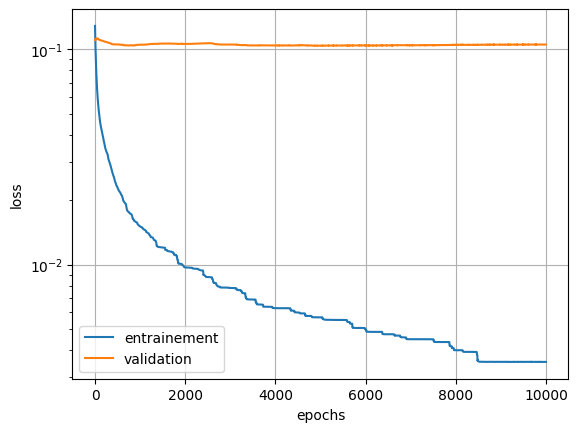

In [5]:
# Plot the loss on train and validation dataset
plt.semilogy(loss_value_train_all[:], label = 'entrainement')
plt.semilogy(loss_value_validation_all[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()